# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [56]:
STUDENT_NAME = "Nguyễn Hoàng Nhân"  # TODO: Họ và tên
STUDENT_ID = "2412415"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Hoàng Nhân (2412415)


In [57]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\Machine Learning\HomeWork\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [58]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [59]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...
# Bước 1: trừ max theo từng hàng để tránh np.exp bị overflow với logit rất lớn.
row_max = logits.max(axis=1, keepdims=True)
shifted_logits = logits - row_max

# Bước 2: exponentiate logits đã shift.
exp_logits = np.exp(shifted_logits)

# Bước 3: chia cho tổng exp trên từng hàng để ra xác suất softmax.
class_probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)

# Bước 4: class dự đoán là class có xác suất lớn nhất.
predicted_classes = np.argmax(class_probabilities, axis=1)

# Bước 5: confidence là xác suất lớn nhất của mỗi mẫu.
confidence_scores = np.max(class_probabilities, axis=1)

print("Shifted logits:\n", shifted_logits)
print("Class probabilities:\n", class_probabilities)
print("Predicted classes:", predicted_classes)
print("Confidence scores:", confidence_scores)

Shifted logits:
 [[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
Class probabilities:
 [[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
Predicted classes: [0 1 2 0]
Confidence scores: [0.65900114 0.66524096 0.97555875 0.33333333]


In [60]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [61]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [62]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...
# axis=0 nghĩa là tính theo từng cột feature.
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)

# Nếu có feature std = 0 thì đổi thành 1 để tránh chia cho 0.
# Dataset này không có std = 0, nhưng viết vậy giúp code an toàn hơn.
train_feature_std = np.where(train_feature_std == 0, 1.0, train_feature_std)

# Dùng cùng mean/std của train để transform cả train và validation.
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

print("Train mean:", train_feature_mean)
print("Train std:", train_feature_std)
print("X_train_scaled mean:", X_train_scaled.mean(axis=0))
print("X_train_scaled std:", X_train_scaled.std(axis=0))
print("X_val_scaled:\n", X_val_scaled)

Train mean: [172.5         69.16666667   1.65        28.16666667]
Train std: [ 7.47774476 13.04372987  0.79109629  7.64671316]
X_train_scaled mean: [ 0.00000000e+00 -3.70074342e-16  3.70074342e-16 -1.48029737e-16]
X_train_scaled std: [1. 1. 1. 1.]
X_val_scaled:
 [[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [63]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [64]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [65]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...
# correct_mask = True nếu dự đoán đúng nhãn thật.
correct_mask = predicted_classes == true_labels

# high_confidence_mask = True nếu model đủ tự tin theo ngưỡng yêu cầu.
high_confidence_mask = confidence_scores >= confidence_threshold

# Cần review nếu dự đoán sai HOẶC confidence thấp.
review_mask = (~correct_mask) | (~high_confidence_mask)

# Lấy chỉ số các dòng cần kiểm tra thủ công.
review_indices = np.where(review_mask)[0]

print("Correct mask:", correct_mask)
print("High confidence mask:", high_confidence_mask)
print("Review mask:", review_mask)
print("Review indices:", review_indices)

Correct mask: [ True False  True False]
High confidence mask: [False False  True False]
Review mask: [ True  True False  True]
Review indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [66]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [67]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# Flip ngang theo trục W, tức axis=2 vì layout là (B, H, W, C).
# .copy() để augmented_batch có bộ nhớ độc lập với normalized_batch.
augmented_batch = np.flip(normalized_batch, axis=2).copy()

# Kiểm tra copy độc lập: sửa augmented_batch không làm đổi normalized_batch.
augmented_batch[0, 0, 0, 0] = 1.0

print("normalized_batch dtype:", normalized_batch.dtype)
print("normalized_batch range:", normalized_batch.min(), normalized_batch.max())
print("augmented_batch owns independent memory:", not np.shares_memory(normalized_batch, augmented_batch))
print("normalized original pixel:", normalized_batch[0, 0, -1, 0])
print("augmented changed pixel:", augmented_batch[0, 0, 0, 0])

normalized_batch dtype: float32
normalized_batch range: 0.0 0.37254903
augmented_batch owns independent memory: True
normalized original pixel: 0.03529412
augmented changed pixel: 1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho **một mẫu xe** trong bộ dữ liệu Automobile.
2. Ký hiệu missing value trong CSV là dấu **`?`**.
3. `symboling` là mức đánh giá rủi ro bảo hiểm của xe, thường nằm trong khoảng từ **-3 đến 3**; giá trị cao hơn thể hiện mức rủi ro được đánh giá cao hơn.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [68]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...

# D1. Load CSV raw, chưa khai báo na_values để giữ dấu "?" dưới dạng chuỗi.
raw_df = pd.read_csv(DATA_PATH)

# Lưu shape để biết dataset có bao nhiêu dòng/cột.
raw_shape = raw_df.shape

# Đếm tổng số marker "?" trên toàn bộ DataFrame.
raw_missing_marker_count = (raw_df == "?").sum().sum()

print("Raw shape:", raw_shape)
print("Total '?' markers:", raw_missing_marker_count)

display(raw_df.head())
display(raw_df.dtypes)

Raw shape: (205, 26)
Total '?' markers: 59


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


symboling              int64
normalized_losses        str
make                     str
fuel_type                str
aspiration               str
num_doors                str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_cylinders            str
engine_size            int64
fuel_system              str
bore                     str
stroke                   str
compression_ratio    float64
horsepower               str
peak_rpm                 str
city_mpg               int64
highway_mpg            int64
price                    str
dtype: object

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [69]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [70]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...
# D2. Tạo bản copy sạch để không làm thay đổi raw_df gốc.
df_clean = raw_df.replace("?", np.nan).copy()

# Ép các cột numeric về dạng số. errors="coerce" giúp giá trị lỗi thành NaN.
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

# Báo cáo số lượng missing theo từng cột, sort giảm dần để dễ nhìn cột thiếu nhiều nhất.
missing_by_column = df_clean.isna().sum().sort_values(ascending=False)

print("Missing values by column:")
display(missing_by_column[missing_by_column > 0])

print("Dtypes after cleaning:")
display(df_clean.dtypes)

Missing values by column:


normalized_losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak_rpm              2
num_doors             2
dtype: int64

Dtypes after cleaning:


symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_doors                str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_cylinders            str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

Không nên fill tất cả numeric columns bằng cùng một giá trị vì mỗi cột có đơn vị và phân phối khác nhau, ví dụ `price` là USD còn `horsepower` là mã lực. Nếu dùng một giá trị chung, dữ liệu có thể bị méo và các thống kê như mean, correlation trở nên kém tin cậy.

Với `price`, trong bài EDA này em chọn **drop các dòng thiếu price** khi phân tích liên quan đến giá, vì giá là biến cần quan sát chính và chỉ thiếu 4 dòng nên mất mát dữ liệu nhỏ.

`normalized_losses` thiếu 41 dòng, nhiều hơn rõ rệt so với các cột khác, nên nếu phân tích cột này cần cẩn thận vì việc drop có thể làm giảm nhiều mẫu hoặc việc fill có thể tạo bias.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [71]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [72]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...

analysis_df = df_clean.dropna(subset=AUTO_FEATURES).copy()

# Chuyển DataFrame sang NumPy float64 để tính toán số học ổn định.
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)

# Tính mean/std theo từng feature.
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)

# Nếu std = 0 thì đổi thành 1 để tránh chia cho 0.
auto_feature_std = np.where(auto_feature_std == 0, 1.0, auto_feature_std)

# Chuẩn hóa z-score: mỗi feature có mean xấp xỉ 0 và std xấp xỉ 1.
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("X_auto shape:", X_auto.shape)
print("Feature mean:", dict(zip(AUTO_FEATURES, auto_feature_mean.round(3))))
print("Feature std:", dict(zip(AUTO_FEATURES, auto_feature_std.round(3))))
print("Scaled mean:", X_auto_scaled.mean(axis=0).round(6))
print("Scaled std:", X_auto_scaled.std(axis=0).round(6))

analysis_df shape: (199, 26)
X_auto shape: (199, 6)
Feature mean: {'curb_weight': np.float64(2556.03), 'engine_size': np.float64(126.824), 'horsepower': np.float64(103.397), 'city_mpg': np.float64(25.201), 'highway_mpg': np.float64(30.683), 'price': np.float64(13243.432)}
Feature std: {'curb_weight': np.float64(518.548), 'engine_size': np.float64(41.648), 'horsepower': np.float64(37.459), 'city_mpg': np.float64(6.436), 'highway_mpg': np.float64(6.832), 'price': np.float64(7958.635)}
Scaled mean: [ 0.  0.  0. -0.  0. -0.]
Scaled std: [1. 1. 1. 1. 1. 1.]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [73]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...
price_index = AUTO_FEATURES.index("price")
price_z = X_auto_scaled[:, price_index]

# Outlier trong bài này là dòng có |z| > 2.
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.loc[price_outlier_mask].copy()

# Thêm cột price_z để giải thích outlier dễ hơn.
price_outliers["price_z"] = price_z[price_outlier_mask]

# Sắp xếp giá giảm dần để xem xe đắt nhất trước.
price_outliers = price_outliers.sort_values("price", ascending=False)

print("Number of price outliers:", price_outlier_mask.sum())

display(
    price_outliers[
        [
            "make",
            "body_style",
            "engine_size",
            "horsepower",
            "city_mpg",
            "highway_mpg",
            "price",
            "price_z",
        ]
    ]
)

Number of price outliers: 14


,make,body_style,engine_size,horsepower,city_mpg,highway_mpg,price,price_z
74,mercedes-benz,hardtop,304,184.0,14,16,45400.0,4.040463
16,bmw,sedan,209,182.0,16,22,41315.0,3.527184
73,mercedes-benz,sedan,308,184.0,14,16,40960.0,3.482578
128,porsche,convertible,194,207.0,17,25,37028.0,2.988523
17,bmw,sedan,209,182.0,15,20,36880.0,2.969927
49,jaguar,sedan,326,262.0,13,17,36000.0,2.859356
48,jaguar,sedan,258,176.0,15,19,35550.0,2.802813
72,mercedes-benz,convertible,234,155.0,16,18,35056.0,2.740742
71,mercedes-benz,sedan,234,155.0,16,18,34184.0,2.631176
127,porsche,hardtop,194,207.0,17,25,34028.0,2.611574


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [74]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...
engine_size_values = X_auto[:, AUTO_FEATURES.index("engine_size")]
price_values = X_auto[:, AUTO_FEATURES.index("price")]

engine_price_corr = np.corrcoef(engine_size_values, price_values)[0, 1]

# Mean price theo body_style, bỏ các dòng không có price.
price_by_body_style = (
    df_clean.dropna(subset=["price"])
    .groupby("body_style")["price"]
    .mean()
    .sort_index()
)

print("Correlation engine_size vs price:", engine_price_corr)
display(price_by_body_style)

Correlation engine_size vs price: 0.8738869517981515


body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

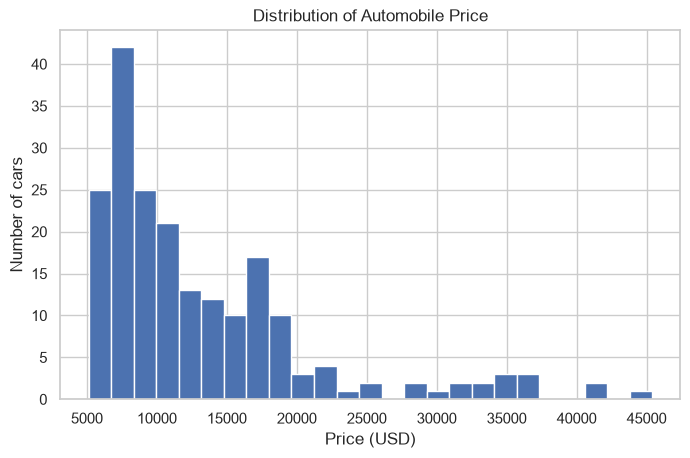

In [75]:
# TODO M2.1: histogram/KDE của price
price_series = df_clean["price"].dropna()

plt.figure(figsize=(8, 4.8))
plt.hist(price_series, bins=25)
plt.title("Distribution of Automobile Price")
plt.xlabel("Price (USD)")
plt.ylabel("Number of cars")
plt.show()

**Nhận xét:**Phân phối `price` lệch phải: đa số xe nằm ở vùng giá thấp đến trung bình, trong khi một số ít xe có giá rất cao kéo đuôi phân phối sang phải. Median khoảng 10,295 USD thấp hơn mean khoảng 13,207 USD, phù hợp với phân phối lệch phải.

## M2.2 Dataset có cân bằng theo body style không?

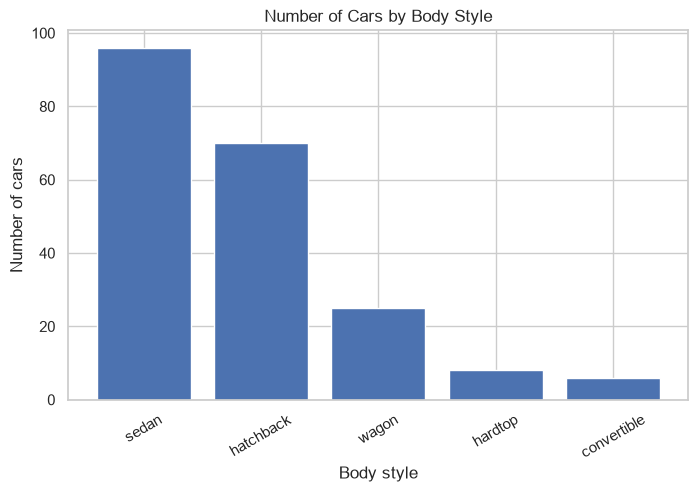

In [76]:
# TODO M2.2: countplot của body_style
body_counts = df_clean["body_style"].value_counts()

plt.figure(figsize=(8, 4.8))
plt.bar(body_counts.index, body_counts.values)
plt.title("Number of Cars by Body Style")
plt.xlabel("Body style")
plt.ylabel("Number of cars")
plt.xticks(rotation=30)
plt.show()

**Nhận xét:** Dataset không cân bằng theo `body_style`: sedan và hatchback xuất hiện nhiều nhất, còn convertible và hardtop có rất ít mẫu. Điều này khiến các thống kê theo nhóm nhỏ dễ kém ổn định hơn.

## M2.3 Price khác nhau theo body style ra sao?

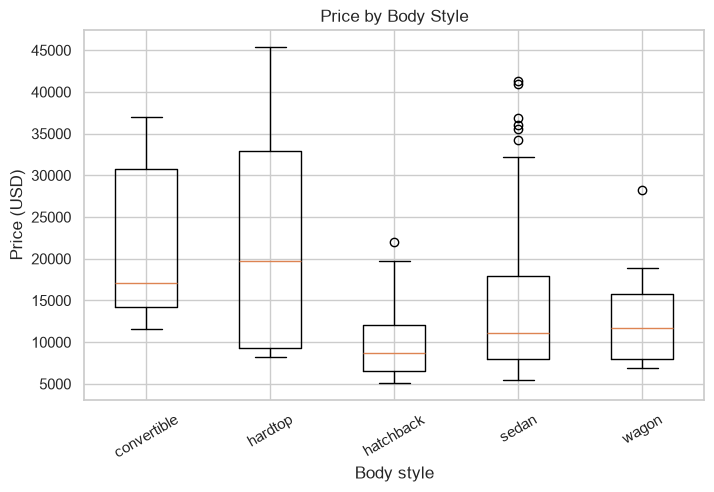

In [77]:
# TODO M2.3: boxplot price theo body_style
# Câu hỏi: Price khác nhau theo body style ra sao?
plot_df = df_clean.dropna(subset=["price", "body_style"])

body_styles = sorted(plot_df["body_style"].unique())
price_groups = [
    plot_df.loc[plot_df["body_style"] == style, "price"]
    for style in body_styles
]

plt.figure(figsize=(8, 4.8))
plt.boxplot(price_groups, tick_labels=body_styles)
plt.title("Price by Body Style")
plt.xlabel("Body style")
plt.ylabel("Price (USD)")
plt.xticks(rotation=30)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

## M2.4 Engine size liên quan thế nào tới price?

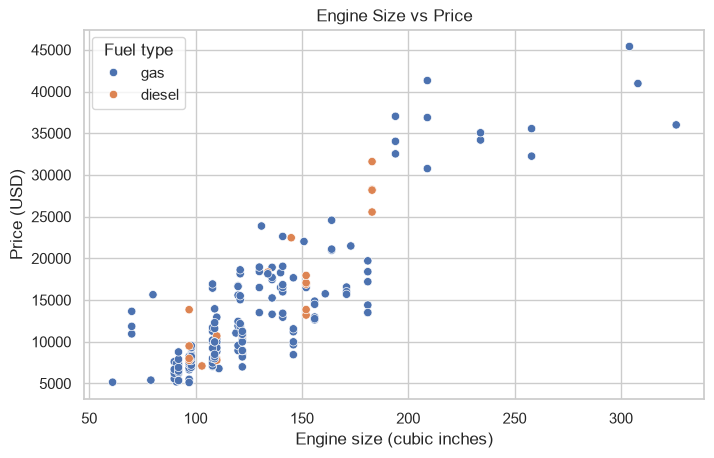

In [78]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
# Câu hỏi: Engine size liên quan thế nào tới price?
plt.figure(figsize=(8, 4.8))
sns.scatterplot(data=analysis_df, x="engine_size", y="price", hue="fuel_type")
plt.title("Engine Size vs Price")
plt.xlabel("Engine size (cubic inches)")
plt.ylabel("Price (USD)")
plt.legend(title="Fuel type")
plt.show()

**Nhận xét:** `engine_size` và `price` có quan hệ dương khá mạnh: xe có dung tích động cơ lớn thường có giá cao hơn. Pearson correlation giữa hai biến này khoảng 0.874, nhưng đây chỉ là tương quan, chưa chứng minh engine size trực tiếp gây ra giá cao.

## M2.5 Các feature numeric tương quan ra sao?

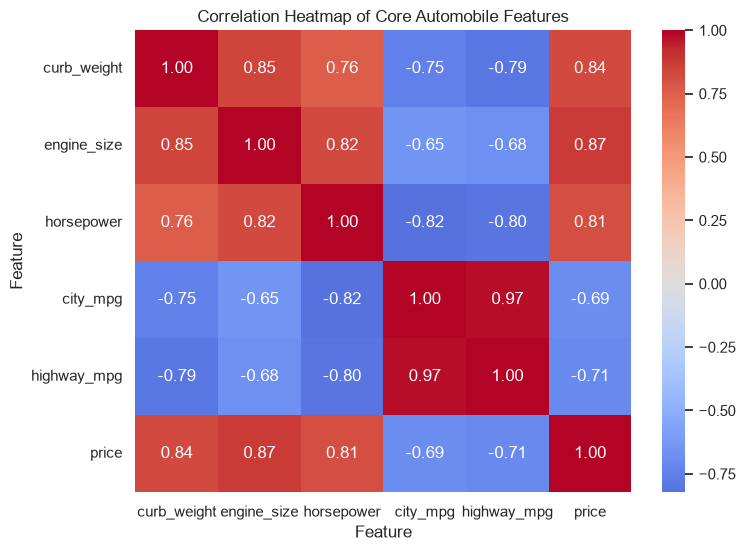

In [79]:
# TODO M2.5: correlation heatmap
# Câu hỏi: Các feature numeric tương quan ra sao?
corr_matrix = analysis_df[AUTO_FEATURES].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Core Automobile Features")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.show()

**Nhận xét:** `price` tương quan dương mạnh với `engine_size`, `curb_weight` và `horsepower`. Ngược lại, `city_mpg` và `highway_mpg` tương quan âm với `price`, nghĩa là xe đắt hơn thường tiêu hao nhiên liệu nhiều hơn trong dataset này.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

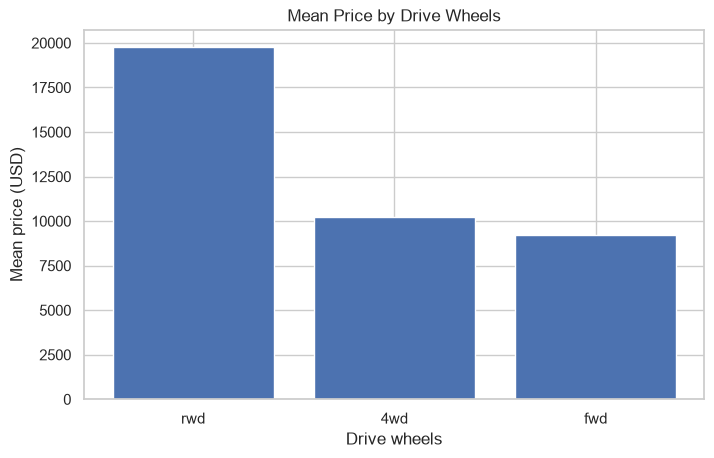

drive_wheels
rwd    19757.613333
4wd    10241.000000
fwd     9244.779661
Name: price, dtype: float64

In [80]:
# TODO M2.6: biểu đồ tự chọn
# Câu hỏi tự chọn: Hệ dẫn động khác nhau có mức giá trung bình khác nhau không?
drive_price = (
    df_clean.dropna(subset=["price"])
    .groupby("drive_wheels")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4.8))
plt.bar(drive_price.index, drive_price.values)
plt.title("Mean Price by Drive Wheels")
plt.xlabel("Drive wheels")
plt.ylabel("Mean price (USD)")
plt.show()

display(drive_price)

**Nhận xét:** Nhóm `rwd` có mean price cao nhất, khoảng 19,758 USD, cao hơn nhiều so với `fwd` khoảng 9,245 USD. Tuy vậy, cần kiểm tra thêm các yếu tố như hãng xe, engine size và phân khúc xe trước khi kết luận hệ dẫn động làm giá tăng.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

## Tổng hợp của sinh viên

Qua EDA trên bộ Automobile, em rút ra một số phát hiện chính. Thứ nhất, phân phối `price` bị lệch phải: phần lớn xe có giá thấp đến trung bình, trong khi một số xe rất đắt làm mean khoảng 13,207 USD cao hơn median khoảng 10,295 USD. Thứ hai, dataset không cân bằng theo `body_style`; sedan và hatchback chiếm nhiều mẫu nhất, còn convertible và hardtop có rất ít mẫu nên thống kê của hai nhóm này cần được diễn giải cẩn thận. Thứ ba, `engine_size` có tương quan dương mạnh với `price`, khoảng 0.874, cho thấy xe có động cơ lớn thường đi kèm giá cao hơn. Thứ tư, các biến tiết kiệm nhiên liệu như `city_mpg` và `highway_mpg` tương quan âm với `price`, nghĩa là xe giá cao trong dataset này thường tiêu hao nhiên liệu nhiều hơn.

Dataset cũng có hạn chế: một số cột bị thiếu dữ liệu, đặc biệt `normalized_losses` thiếu 41 dòng; ngoài ra dữ liệu là bộ 1985 Auto Imports nên có thể không đại diện cho thị trường xe hiện nay. Correlation không đồng nghĩa causation: `engine_size` tương quan cao với `price`, nhưng giá còn có thể do thương hiệu, phân khúc, thiết kế, trang bị và nhiều yếu tố khác. Câu hỏi nên phân tích tiếp là: sau khi kiểm soát `make`, `body_style` và `drive_wheels`, `engine_size` còn giải thích được bao nhiêu biến thiên của `price`?